In [ ]:
%pip install -Uqq transformers

In [1]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 625, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 625 (delta 146), reused 86 (delta 85), pack-reused 434 (from 3)
Receiving objects: 100% (625/625), 206.72 KiB | 3.83 MiB/s, done.
Resolving deltas: 100% (320/320), done.


In [2]:
import torch
import time
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from scipy.stats import mode
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from cuml.svm import SVC
import gc
import os
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

In [3]:
class RatingDataset(Dataset):
    def __init__(self, texts, targets, tokenizer, max_len):
        self.texts = texts
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        # Only include labels if they exist
        if self.targets is not None:
            target = self.targets[item]
            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(target, dtype=torch.long)
            }
        else:
            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
            }

In [4]:
MODEL_REPO = "DeepPavlov/rubert-base-cased-conversational"
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_REPO)
MAX_LENGTH = 512
BATCH_SIZE = 8
ACCUMULATION_STEPS = 4
NUM_EPOCHS = 3
NUM_FOLDS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LEARNING_RATE = 1e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
DROPOUT_RATE = 0.3

print(f"Using device: {DEVICE}")
print(f"Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}")


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Using device: cuda
Effective batch size: 32


In [5]:
class StableArcFaceLoss(nn.Module):
    def __init__(self, embedding_size, num_classes, margin=0.5, scale=64, label_smoothing=0.1):
        super().__init__()
        self.margin = margin
        self.scale = scale
        self.num_classes = num_classes
        self.label_smoothing = label_smoothing
        
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        
        # CrossEntropyLoss with Label Smoothing
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        
    def forward(self, embeddings, labels, logits):
        normalized_embeddings = nn.functional.normalize(embeddings)
        normalized_weight = nn.functional.normalize(self.weight)
        
        cosine = torch.matmul(normalized_embeddings, normalized_weight.t())
        cosine = torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7)
        
        # ArcFace margin calculation
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        margin_tensor = torch.tensor(self.margin, device=cosine.device, dtype=cosine.dtype)
        
        phi = cosine * torch.cos(margin_tensor) - sine * torch.sin(margin_tensor)
        
        arcface_logits = phi * self.scale
        
        # Combined loss (Gradual introduction of ArcFace)
        ce_loss = self.ce_loss(logits, labels)
        arcface_loss = self.ce_loss(arcface_logits, labels)
        
        return ce_loss + 0.05 * arcface_loss

class StableBertForMultiClassClassification(nn.Module):
    def __init__(self, model_name, num_classes=5, dropout=DROPOUT_RATE):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        
        # Feature transformation layers (768 is BERT's hidden size)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.hidden = nn.Linear(768, 384)
        self.activation = nn.GELU()
        self.classifier = nn.Linear(384, num_classes)
        
        self.arcface = StableArcFaceLoss(384, num_classes)
        
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.constant_(self.classifier.bias, 0.0)
        
    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :] # [CLS] token pooling
        
        hidden_output = self.activation(self.hidden(self.dropout1(pooled_output)))
        logits = self.classifier(self.dropout2(hidden_output))
        
        loss = None
        if labels is not None:
            # Pass hidden_output (features for ArcFace), labels, and logits to loss
            loss = self.arcface(hidden_output, labels, logits) 
            
        return loss, logits, hidden_output # Return hidden features for SVM

print("Stable model architecture defined!")

Stable model architecture defined!


In [7]:
def get_optimizer_with_lrld(model, learning_rate=LEARNING_RATE, layer_decay=0.95):
    """Layer-wise Learning Rate Decay (LLRD) for stability."""
    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    optimizer_grouped_parameters = []
    
    bert_layers = [model.bert.embeddings] + list(model.bert.encoder.layer)
    num_layers = len(bert_layers)
    
    for layer_idx, layer in enumerate(bert_layers):
        layer_lr = learning_rate * (layer_decay ** (num_layers - layer_idx))
        
        # Parameters with weight decay
        params_decay = {
            "params": [p for n, p in layer.named_parameters() 
                       if not any(nd in n for nd in no_decay)],
            "weight_decay": WEIGHT_DECAY,
            "lr": layer_lr,
        }
        
        # Parameters without weight decay  
        params_no_decay = {
            "params": [p for n, p in layer.named_parameters() 
                       if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": layer_lr,
        }
        
        optimizer_grouped_parameters.extend([params_decay, params_no_decay])
    
    # Classifier, Hidden, and ArcFace layers (higher LR)
    classifier_params = {
        "params": list(model.classifier.parameters()) + list(model.hidden.parameters()),
        "weight_decay": WEIGHT_DECAY,
        "lr": learning_rate * 2.0,
    }
    arcface_params = {
        "params": model.arcface.parameters(),
        "weight_decay": WEIGHT_DECAY, 
        "lr": learning_rate * 1.5,
    }
    optimizer_grouped_parameters.extend([classifier_params, arcface_params])
    
    return AdamW(optimizer_grouped_parameters, eps=1e-8)

print("LLRD optimizer defined!")

LLRD optimizer defined!


In [8]:
def train_svm_for_fold(features, targets, fold_idx, C=1.0):
    """
    Trains cuML SVC with default parameters, relying on BERT/ArcFace 
    features and StratifiedKFold for imbalance.
    """
    print(f"  Training cuML SVC for Fold {fold_idx + 1} with default parameters...")
    
    # Using cuML's GPU-accelerated SVC
    svm = SVC(
        C=C, 
        kernel='rbf', 
        gamma='auto', 
        probability=False,
        cache_size=8000
    )
    
    # Train without class_weight or sample_weight
    svm.fit(features, targets)
    
    print(f"  cuML SVC training complete using default parameters.")
    return svm

In [9]:
def extract_features(model, data_loader, device):
    """Extracts 384-dimensional hidden features for SVC training or inference."""
    model.eval()
    all_features = []
    all_labels = []
    
    # Check if this is a test loader (no labels)
    has_labels = 'labels' in data_loader.dataset[0]

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Extracting Features"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Get the hidden_output (384-dim feature vector)
            _, _, hidden_output = model(input_ids, attention_mask)
            
            all_features.append(hidden_output.cpu().numpy())
            
            if has_labels:
                labels = batch['labels'].to(device)
                all_labels.append(labels.cpu().numpy())

    if has_labels:
        return np.vstack(all_features), np.concatenate(all_labels)
    else:
        return np.vstack(all_features)

In [17]:
def train_bert_for_fold(train_loader, val_loader, model, device, fold_idx, num_epochs=NUM_EPOCHS):
    """Core BERT fine-tuning loop."""
    print(f"\n=== Training Fold {fold_idx + 1} ===")
    
    optimizer = get_optimizer_with_lrld(model, learning_rate=LEARNING_RATE)
    
    scaler = torch.amp.GradScaler('cuda')
    
    num_training_steps = len(train_loader) * num_epochs // ACCUMULATION_STEPS
    num_warmup_steps = int(num_training_steps * WARMUP_RATIO)
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
    
    best_val_f1 = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        optimizer.zero_grad()
        
        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Fold {fold_idx+1} Epoch {epoch+1}")):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Mixed precision forward pass
            with torch.amp.autocast('cuda'):
                loss, _, _ = model(input_ids, attention_mask, labels)
                loss = loss / ACCUMULATION_STEPS
            
            # Scaled backward pass
            scaler.scale(loss).backward()
            
            total_train_loss += loss.item() * ACCUMULATION_STEPS
            
            if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
                # Unscale before clipping
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                
                # Optimizer step with scaler
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        
        torch.cuda.synchronize()
        print(f"\n✅ Training epoch {epoch+1} completed. Starting validation...")
        
        model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                _, logits, _ = model(input_ids, attention_mask)
                preds = torch.argmax(logits, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        
        print(f"\nFold {fold_idx+1}, Epoch {epoch+1} Results:")
        print(f"  Train Loss: {total_train_loss / len(train_loader):.4f}")
        print(f"  Val F1: {val_f1:.4f}")

        checkpoint_filename = f'/kaggle/working/fold_{fold_idx}_epoch_{epoch}_checkpoint.pt'
        torch.save(model.state_dict(), checkpoint_filename)
        print(f"  Checkpoint saved to {checkpoint_filename}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f'/kaggle/working/fold_{fold_idx}_best_bert.pt')
            print(f"  New best BERT model saved with F1: {best_val_f1:.4f}")
            
    model.load_state_dict(torch.load(f'/kaggle/working/fold_{fold_idx}_best_bert.pt'))
    return model

Initial dataset size: 48665 samples.


<Axes: >

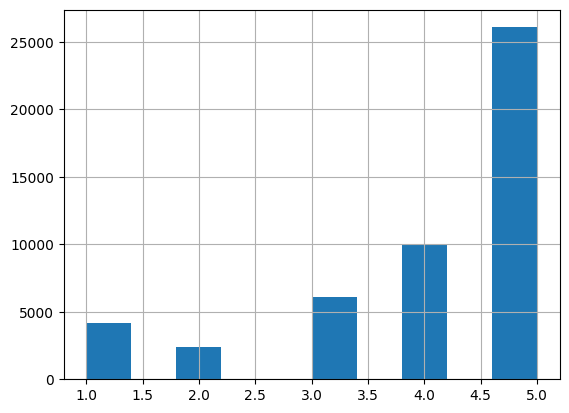

In [11]:
DATA_PATH = '/kaggle/input/reviews/train.csv' 
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'rate'

train = pd.read_csv(DATA_PATH) 

print(f"Initial dataset size: {len(train)} samples.")
train = pd.read_csv("/kaggle/input/reviews/train.csv")
train = train[[TEXT_COLUMN, LABEL_COLUMN]]
train[LABEL_COLUMN].hist()

In [12]:
duplicates = train[train.duplicated(subset=[TEXT_COLUMN, LABEL_COLUMN], keep=False)]
duplicate_groups = duplicates.groupby([TEXT_COLUMN, LABEL_COLUMN])
for (text, rate), group in list(duplicate_groups)[:5]: 
    print(f"\n---")
    for idx, row in group.iterrows():
        print(f"Text: {row[TEXT_COLUMN][:1000]}...")
        print(f"Rate: {row[LABEL_COLUMN]}")
        print("---")
    


---
Text:  Сырое тесто в выпечке...
Rate: 1
---
Text:  Сырое тесто в выпечке...
Rate: 1
---

---
Text: Ассортимент маленький...
Rate: 3
---
Text: Ассортимент маленький...
Rate: 3
---

---
Text: Большие очереди...
Rate: 3
---
Text: Большие очереди...
Rate: 3
---
Text: Большие очереди...
Rate: 3
---

---
Text: Большой ассортимент товаров....
Rate: 5
---
Text: Большой ассортимент товаров....
Rate: 5
---

---
Text: Большой ассортимент, вежливые кассиры...
Rate: 5
---
Text: Большой ассортимент, вежливые кассиры...
Rate: 5
---


In [13]:
df_deduplicated = train.drop_duplicates(
    subset=[TEXT_COLUMN, LABEL_COLUMN], 
    keep='first'
).copy()

# Remove any samples where the text is empty/NaN
df_deduplicated = df_deduplicated.dropna(subset=[TEXT_COLUMN]).copy()
df_deduplicated = df_deduplicated[df_deduplicated[TEXT_COLUMN].astype(str).str.strip() != ''].copy()
df_deduplicated[LABEL_COLUMN] = df_deduplicated[LABEL_COLUMN].astype(np.int64)

# Extract the clean texts and labels
texts = df_deduplicated[TEXT_COLUMN].tolist()
targets = df_deduplicated[LABEL_COLUMN].values - 1

In [14]:
NUM_SAMPLES = len(targets)
unique_labels, counts = np.unique(targets, return_counts=True)
count_dict = dict(zip(unique_labels, counts))

print(f"Deduplicated size: {NUM_SAMPLES} samples (Removed {len(train) - NUM_SAMPLES} duplicates).")
print(f"✅ Clean Data loaded successfully.")
print(f"Class distribution after deduplication: {count_dict}")

Deduplicated size: 47174 samples (Removed 1491 duplicates).
✅ Clean Data loaded successfully.
Class distribution after deduplication: {0: 4130, 1: 2407, 2: 6070, 3: 9763, 4: 24804}


In [15]:
train_texts, test_texts, train_targets, test_targets = train_test_split(
    texts, targets, 
    test_size=0.1, 
    random_state=42,
    stratify=targets
)

print(f"Train: {len(train_texts):,} samples")
print(f"Test: {len(test_texts):,} samples")
print(f"Test set represents {len(test_texts)/len(texts)*100:.1f}% of total")

Train: 42,456 samples
Test: 4,718 samples
Test set represents 10.0% of total


In [18]:
print("\n=== STARTING 5-FOLD CROSS VALIDATION AND ENSEMBLE ===")

full_dataset = RatingDataset(train_texts, train_targets, TOKENIZER, MAX_LENGTH)

folds_file = '/kaggle/working/cross_validation_folds.pkl'
if os.path.exists(folds_file):
    print("Loading existing folds...")
    folds = joblib.load(folds_file)
else:
    print("Creating new folds...")
    skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
    folds = list(skf.split(train_texts, train_targets))
    joblib.dump(folds, folds_file)

completed_folds_file = '/kaggle/working/completed_folds.pkl'
if os.path.exists(completed_folds_file):
    completed_folds = joblib.load(completed_folds_file)
    print(f"Found {len(completed_folds)} completed folds: {completed_folds}")
else:
    completed_folds = []
    print("Starting fresh - no completed folds found")

fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\n{'='*60}")
    print(f"Processing Fold {fold_idx + 1}/{NUM_FOLDS}")
    print(f"{'='*60}")

    result_file = f'/kaggle/working/fold_{fold_idx}_result.pkl'
    if os.path.exists(result_file):
        fold_result = joblib.load(result_file)
        fold_results.append(fold_result)
        print(f"Loaded previous result: F1 = {fold_result:.4f}")
        continue
    
    # Setup DataLoaders
    train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(full_dataset, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Initialize and Train BERT Model
    model = StableBertForMultiClassClassification(MODEL_REPO).to(DEVICE)
    trained_bert = train_bert_for_fold(
        train_loader, val_loader, model, DEVICE, fold_idx
    )
    
    # Extract features from the validation set
    val_features, val_targets_cv = extract_features(trained_bert, val_loader, DEVICE)
    # Extract features from the training set (for SVM training)
    train_features, train_svm_targets = extract_features(trained_bert, train_loader, DEVICE)
    
    # Train SVC Ensemble Component
    svm_model = train_svm_for_fold(train_features, train_svm_targets, fold_idx)

    joblib.dump(svm_model, f'/kaggle/working/fold_{fold_idx}_svc.joblib')
    print(f"  Fold {fold_idx + 1} SVC model saved.")
    
    # Evaluate Ensemble Performance on Validation Set
    svm_val_preds = svm_model.predict(val_features)
    
    # The final ensemble prediction is the SVM result on BERT features
    ensemble_f1 = f1_score(val_targets_cv, svm_val_preds, average='weighted')
    fold_results.append(ensemble_f1)
    
    print(f"\nFold {fold_idx + 1} Ensemble (BERT Features + SVC) F1: **{ensemble_f1:.4f}**")

    joblib.dump(ensemble_f1, f'/kaggle/working/fold_{fold_idx}_result.pkl')
    completed_folds.append(fold_idx)
    joblib.dump(completed_folds, completed_folds_file)
    
    # Clean up GPU memory
    del trained_bert, svm_model, val_features, train_features
    torch.cuda.empty_cache()
    gc.collect()

# Final Results
print(f"\n{'='*60}")
print("=== FINAL ENSEMBLE CROSS-VALIDATION RESULTS ===")
print(f"Individual Fold F1 Scores: {np.round(fold_results, 4)}")
print(f"Overall Mean Weighted F1: **{np.mean(fold_results):.4f}** ± **{np.std(fold_results):.4f}**")
print(f"{'='*60}")


=== STARTING 5-FOLD CROSS VALIDATION AND ENSEMBLE ===
Loading existing folds...
Starting fresh - no completed folds found

Processing Fold 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Training Fold 1 ===


Fold 1 Epoch 1:   0%|          | 0/4246 [00:00<?, ?it/s]

...

Fold 5 Epoch 3:   0%|          | 0/4246 [00:00<?, ?it/s]


✅ Training epoch 3 completed. Starting validation...

Fold 5, Epoch 3 Results:
  Train Loss: 0.9677
  Val F1: 0.6701
  Checkpoint saved to /kaggle/working/fold_4_epoch_2_checkpoint.pt
  New best BERT model saved with F1: 0.6701


Extracting Features:   0%|          | 0/1062 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/4246 [00:00<?, ?it/s]

  Training cuML SVC for Fold 5 with default parameters...
  cuML SVC training complete using default parameters.
  Fold 5 SVC model saved.

Fold 5 Ensemble (BERT Features + SVC) F1: **0.6640**

=== FINAL ENSEMBLE CROSS-VALIDATION RESULTS ===
Individual Fold F1 Scores: [0.6578 0.6592 0.6624 0.6632 0.664 ]
Overall Mean Weighted F1: **0.6613** ± **0.0024**


In [19]:
train_targets_original = train_targets + 1
test_targets_original = test_targets + 1

train_df = pd.DataFrame({
    TEXT_COLUMN: train_texts,
    LABEL_COLUMN: train_targets_original
})

test_df = pd.DataFrame({
    TEXT_COLUMN: test_texts,
    LABEL_COLUMN: test_targets_original
})

train_df.to_csv('/kaggle/working/train_split.csv', index=False, encoding='utf-8')
test_df.to_csv('/kaggle/working/test_split.csv', index=False, encoding='utf-8')

print(f"\nSaved train set to: /kaggle/working/train_split.csv")
print(f"Saved test set to: /kaggle/working/test_split.csv")



Saved train set to: /kaggle/working/train_split.csv
Saved test set to: /kaggle/working/test_split.csv


In [25]:
MODEL_SAVE_DIR = '/kaggle/working'

print("Starting test set prediction...")

test_dataset = RatingDataset(test_texts, None, TOKENIZER, MAX_LENGTH) 
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_fold_predictions = []
test_f1_scores = []

test_true_labels = test_targets

for fold_idx in range(NUM_FOLDS):
    print(f"\n--- Predicting with Fold {fold_idx + 1}/{NUM_FOLDS} ---")
    
    print("  Loading BERT model...")
    bert_model_path = os.path.join(MODEL_SAVE_DIR, f'fold_{fold_idx}_best_bert.pt')
    model = StableBertForMultiClassClassification(MODEL_REPO).to(DEVICE)
    model.load_state_dict(torch.load(bert_model_path))
    
    test_features = extract_features(model, test_loader, DEVICE)
    
    print("  Loading SVC model...")
    svc_model_path = os.path.join(MODEL_SAVE_DIR, f'fold_{fold_idx}_svc.joblib')
    svm_model = joblib.load(svc_model_path)
    
    print("  Getting SVC predictions...")
    fold_preds = svm_model.predict(test_features)
    all_fold_predictions.append(fold_preds)

    fold_f1 = f1_score(test_true_labels, fold_preds, average='weighted')
    test_f1_scores.append(fold_f1)
    
    print(f"  Fold {fold_idx + 1} Test F1: {fold_f1:.4f}")
    
    # Clean up
    del model, svm_model, test_features, fold_preds
    torch.cuda.empty_cache()
    gc.collect()

# Ensemble Predictions using Voting
print("\nEnsembling predictions...")
# Stack predictions: 5 rows (one per model), N columns (one per test sample)
predictions_stack = np.stack(all_fold_predictions)

# Use scipy.stats.mode to find the most common prediction for each sample
ensemble_preds_0_4 = mode(predictions_stack, axis=0)[0].flatten()

ensemble_f1 = f1_score(test_true_labels, ensemble_preds_0_4, average='weighted')

# Final Results - same format as CV results
print(f"\n{'='*60}")
print("=== FINAL TEST SET RESULTS ===")
print(f"Individual Fold F1 Scores: {np.round(test_f1_scores, 4)}")
print(f"Overall Mean Weighted F1: **{np.mean(test_f1_scores):.4f}** ± **{np.std(test_f1_scores):.4f}**")
print(f"Ensemble Weighted F1: **{ensemble_f1:.4f}**")
print(f"{'='*60}")


Starting test set prediction...

--- Predicting with Fold 1/5 ---
  Loading BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting Features:   0%|          | 0/590 [00:00<?, ?it/s]

  Loading SVC model...
  Getting SVC predictions...
  Fold 1 Test F1: 0.6592

--- Predicting with Fold 2/5 ---
  Loading BERT model...


...

  Loading SVC model...
  Getting SVC predictions...
  Fold 4 Test F1: 0.6627

--- Predicting with Fold 5/5 ---
  Loading BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting Features:   0%|          | 0/590 [00:00<?, ?it/s]

  Loading SVC model...
  Getting SVC predictions...
  Fold 5 Test F1: 0.6594

Ensembling predictions...

=== FINAL TEST SET RESULTS ===
Individual Fold F1 Scores: [0.6592 0.661  0.658  0.6627 0.6594]
Overall Mean Weighted F1: **0.6601** ± **0.0016**
Ensemble Weighted F1: **0.6599**
